# Exercise Sheet 06

This markdown block is used to define macros for later markdown blocks. 
$\newcommand{\normaldist}{\mathcal{N}}$
$\newcommand{\betadist}{\text{Beta}}$
$\newcommand{\reals}{\mathbb{R}}$
$\newcommand{\ML}{\text{ML}}$
$\renewcommand{\vec}[1]{\boldsymbol{\mathbf{#1}}}$
$\newcommand{\matrix}[1]{\boldsymbol{\mathbf{#1}}}$
$\newcommand{\dataset}{\mathcal{D}}$
$\newcommand{\class}{\mathcal{C}}$
$\newcommand{\optimal}[1]{#1^{\star}}$
$\newcommand{\argmin}{\text{argmin}}$
$\newcommand{\argmax}{\text{argmax}}$
$\newcommand{\expct}{\mathbb{E}}$
$\newcommand{\entropy}[1]{H[#1]}$
$\newcommand{\conditionalentropy}[2]{\entropy{#1 | #2}}$
$\newcommand{\kldiv}[2]{KL(#1 || #2)}$
$\newcommand{\mutualinfo}[2]{I[#1;#2]}$
$\newcommand{\deriv}[2]{\frac{d}{d #2} \left( #1\right)}$
$\newcommand{\inputs}{\matrix{X}}$
$\newcommand{\identitymtx}{\matrix{I}}$
$\newcommand{\designmtx}{\matrix{\Phi}}$
$\newcommand{\featurevec}{\boldsymbol{\phi}}$

In [1]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import scipy.stats
import pandas as pd
from itertools import groupby

## Exercise 6.1

### ✏️ 6.1 a)

Look again at the slide **Rewriting expected square loss**. Can you show the steps in the derivation for $\expct[L]$. There is a mistake in Bishop's result in Section 1.5.5. Can you spot it? Make sure that the random variables for the expectation and their distribution are made clear by using the sub-script notation on the expectation. Show explicitly each step in the process.

### ✏️ 6.1 b)

Look again at the slide **Bias-variance decomposition**. Look at the result for expectation over the ensemble $\expct_\dataset[(y(\vec{x};\dataset) - h(\vec{x}))^2]$. Convince yourself that the $(\text{bias})^2$ and $\text{variance}$ terms are correct and that the cross term disappears. 

### 💻 6.1 c)

Figure 3.6 in (Bishop, 2006) is shown in slide **Bias-variance summary**. Look again at Equations (3.45), (3.46) and (3.47) and decide how you might create a similar plot for one of the univariate regularisations you performed in Unit 5. You do not need to implement this, just think about how you would do it. However, if you choose to implement it then let me (your module leader) know, as I am sure the class would be interested in the result.


## Exercise 6.1 solutions

*Write your solutions in markdown here.*

## Exercise 6.2

### 💻 6.2 a)

i. Look at the code in the code block below. This recreates the experiments from Figure 3.5 in the Bishop textbook. The results are collated into a `pandas.DataFrame` object, one row per experiment, with the weight vector elements each taking one column. Look at the documentation for a `pandas.DataFrame`, and attempt to recreate the plots from (Bishop, 2006, Figure 3.5). You will need to implement Equation (3.45) from (Bishop, 2006, Sec. 3.2)



### ✏️ 6.2 b)

In the experiments for **Ex. 6 a)**:

i. What was the hypothesis space? Are there different ways of thinking about this hypothesis space?

ii. What scheme of reasoning about hypotheses does this correspond to: noise-free or noisy; optimisation based or Bayesian? Explain your reasons and the features of the experiments that would have to change to make the answer different.

iii. In these experiments, what does a single red line in the left hand plots of (Bishop, 2006, Figure 3.6) correspond to? Can you explain this in the language of hypothesis spaces, datasets, ensembles and plausibility scores? Why are all the red lines different?

### 💻 6.2 c) 

Below is a list of $4$ things you can change in the code from **Ex. 6.2 a)**. In each case, make the change and observe how the plots are affected (if you have completed **Ex. 6.2 d)** you will need to re-run both blocks). Can you explain the changes? Ask yourself in each case: Is the hypothesis space different or the same?

i. Change the number of datapoints `N`.

ii. Change the trend function from `simple_sin` to `arbitrary_function_1`.

iii. Change the number of RBFs `M`.

iv. Keeping `M` the same, change the type of basis function. Or the scale of the RBFs.

### 💻 6.2 d) [optional]

*This relates more to part 1 of the slides and you may choose to do this after watching all the lectures for the unit.*

Look at Equations (3.46) and (3.47) in (Bishop, 2006, Sec. 3.2) for empirical calculations of the (bias)$^2$ and variance on an ensemble of datasets. These are used to plot Figure 3.6 (Bishop, 2006). Your goal is to recreate that plot. To do this, you will need to generate 1000 test data-points on which to evaluate the metrics as well as the RMS test error over each ensemble.

Implement the necessary code and run a new set of ensemble experiments for a range of $\ln\lambda$ values between $-2.5$ and $1.5$ (perhaps $15$ values will give a smooth enough curve).



In [2]:
# for creating synthetic data
from fomlads.data.function import simple_sin
from fomlads.data.function import arbitrary_function_1
from fomlads.data.function import arbitrary_function_2
from fomlads.data.synthetic import sample_1d_regression_data
# for performing regression
from fomlads.model.regression import regularised_ml_weights
from fomlads.model.basis_functions import construct_rbf_feature_mapping
from fomlads.model.regression import construct_feature_mapping_function

## number of data-points
N = 24
true_func = simple_sin
# number of basis functions
M = 24
# specify the centres of the rbf basis functions
centres = np.linspace(0,1,M)
# the width (analogous to standard deviation) of the basis functions
scale = 1.5/M
#
feature_mapping = construct_rbf_feature_mapping(centres, scale)  
ln_lambdas = np.array([2.6,-0.31,-2.4])
num_trials = 100
trial_params = {
    'lambda': [], 'ln_lambda': []}
trial_weights = []
for ln_lambda in ln_lambdas:
    lambda_ = np.exp(ln_lambda)
    for k in range(num_trials):
        # sample data from true underlying function
        inputs, targets = sample_1d_regression_data(N, true_func)
        # convert data matrix into design matrix
        designmtx = feature_mapping(inputs)
        # fit weights
        weights = regularised_ml_weights(designmtx, targets, lambda_)
        trial_params['lambda'].append(lambda_)
        trial_params['ln_lambda'].append(ln_lambda)
        trial_weights.append(weights)

trial_weights = np.array(trial_weights)
results = pd.DataFrame(trial_params)
weight_fields = [f'w{d}' for d in range(M)]
print(f"trial_weights.shape = {trial_weights.shape}")
print(f"len(weight_fields) = {len(weight_fields)}")
results_weights = pd.DataFrame(data=trial_weights, columns=weight_fields)
results = pd.concat([results, results_weights], axis=1)
results

trial_weights.shape = (300, 24)
len(weight_fields) = 24


,lambda,ln_lambda,w0,w1,w2,w3,w4,w5,w6,w7,...,w14,w15,w16,w17,w18,w19,w20,w21,w22,w23
0,13.463738,2.6,-0.009004,0.003090,0.027759,0.062785,0.108157,0.157481,0.191509,0.191979,...,-0.057774,-0.089099,-0.123074,-0.138470,-0.119557,-0.078254,-0.043064,-0.026115,-0.016014,-0.003470
1,13.463738,2.6,0.026206,0.047223,0.072331,0.103398,0.135869,0.146784,0.133596,0.128391,...,-0.078225,-0.075565,-0.057355,-0.035315,-0.027235,-0.047533,-0.083011,-0.087627,-0.041063,0.011824
2,13.463738,2.6,0.024623,0.050254,0.087069,0.124772,0.135311,0.115979,0.103678,0.118282,...,-0.084984,-0.125434,-0.151140,-0.163225,-0.153320,-0.114030,-0.063944,-0.036002,-0.033997,-0.034019
3,13.463738,2.6,0.045627,0.045402,0.036146,0.044319,0.080643,0.116831,0.113034,0.072350,...,-0.066248,-0.082970,-0.120623,-0.172819,-0.197320,-0.171669,-0.124323,-0.085944,-0.058430,-0.035658
4,13.463738,2.6,-0.022150,0.010123,0.061886,0.096271,0.089019,0.061006,0.058587,0.098920,...,-0.052462,-0.041611,-0.057423,-0.088222,-0.114049,-0.127874,-0.119534,-0.084266,-0.043891,-0.019117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.090718,-2.4,-0.249523,0.157803,0.236028,0.011267,0.110448,0.466524,0.370436,-0.030680,...,-0.487352,-0.452877,-0.231700,-0.319762,-0.331250,-0.036002,-0.123601,-0.456973,-0.178142,0.440595
296,0.090718,-2.4,-0.099705,-0.187023,0.033093,0.206852,0.239511,0.599133,0.811585,0.231551,...,-0.043333,-0.166729,-0.273193,-0.324644,-0.317244,-0.186715,-0.131221,-0.291253,-0.220970,0.145554
297,0.090718,-2.4,0.006890,0.086423,0.114023,0.208945,0.389238,0.430269,0.215108,-0.018206,...,-0.314076,0.037021,-0.064848,-0.430797,-0.467929,-0.242921,-0.189773,-0.126844,0.134816,0.220456
298,0.090718,-2.4,-0.500667,0.045206,0.730041,0.238161,-0.370592,0.238609,0.810117,0.340724,...,-0.112618,-0.237208,-0.264332,-0.330498,-0.439988,-0.299392,0.004165,-0.035522,-0.161348,0.049170


In [3]:
## Complete Ex. 6.2 d) here


## Exercise 6.2 solutions

*Write your markdown solutions here.*

## Exercise 6.3

This question explores the posterior over weights induced by a prior and some data.

### 💻 6.3 a)

Look at the function `calculate_weights_posterior` in `fomlads.model.regression`. This function takes a design matrix (`inputs`), a noise precision (`beta`), and a prior mean and covariance matrix for your weights (`m0` and `S0` respectively) as arguments. This function should calculate the posterior mean and covariance matrix for the weights. The code is incomplete. Complete it by correctly calculating the posterioir mean, `mN`, and covariance matrix, `SN`.

*The required calculation is result (6.4) in the lecture notes.*

### ✏️ 6.3 b) 

Look back at Result (5.2) from Unit 5's lecture slides and compare $\vec{m}_N$ in Result (6.4) with $\vec{w}^{\star}$ from Result (5.2). How are they similar? How could you choose values for expression Result (6.4) to make them identical? 

## Exercise 6.3 solutions

*Write your markdown solutions here.*

## Exercise 6.4

### 💻 6.4 a)

The code below samples some synthetic 1d regression data. Your job is to use the functionality you wrote for **Ex. 6.3 a)** to perform Bayesian inference on this data. You will need to provide a prior mean and covariance. You should do the following:
* Plot the true underlying function with a thick green line, and the data-points in blue (as in previous tutorials)
* Plot the mean posterior function with a thick red line on the same plot  (This is equivalent to the MAP estimate. Why?)
* Draw 10 sample weight vectors from the weights posterior, and plot each of these as thin (`linewidth=0.2`) magenta lines, again on the same plot. How would you interpret these lines?

*You can use `plot_function_data_and_approximation` from `fomlads.plot.predictions` as a starting point for your plotting of a predictive distribution. You can use the function: `numpy.random.multivariate_normal` to sample from a multivariate Gaussian distribution. You can choose anything for your prior mean and covariance, but a zero mean and broad isotropic covariance is recommended, e.g. $\vec{m}_0 = \vec{0}$ and $\matrix{S}_{0} = \alpha^{-1} \identitymtx$ with $\alpha=1$.*

### ✏️ 6.4 b)

Look at the results from **Ex. 6.4 a)**. Think about the thin magenta lines drawn on the plot. 

i. How are these similar to the thin red lines drawn in **Ex. 6.2**? How are they different? Try to answer generally in terms of hypothesis spaces, datasets, and plausibilities.

ii. What do the magenta lines together tell you about what you're algorithm has learned? Think about the example from the slide entitled **Bayesian Linear Regression Illustrated**. What are the equivalent elements on your plot of the red lines on the right hand plots of the slide? On the slide plots, the middle column shows the prior and posterior over weights, what does your prior and posterior *look like*?

ii. How would what you observe on your plot be different if you used fewer training data-points? What about if you had more data-points? What about if you had more basis functions?

iii. How would things be different if you used purely linear regression with Bayesian inference? What about polynomial regression?


In [4]:
# for performing regression
from fomlads.model.regression import calculate_weights_posterior
# for plotting results
from fomlads.plot.predictions import plot_function_and_data
from fomlads.plot.predictions import plot_function_data_and_approximation
from fomlads.plot.evaluations import plot_train_test_errors

M = 12
# specify the centres of the rbf basis functions
centres = np.linspace(0,1,M)
# the width (analogous to standard deviation) of the basis functions
scale = 1.5/M
print(f"centres = {np.round(centres,3)}")
print(f"scale = {scale}")
# create the feature mapping
feature_mapping = construct_rbf_feature_mapping(centres,scale)  

# sample number of data-points: inputs and targets
N = 9
# define the precision of our noise
beta = (1./0.1)**2
inputs, targets = sample_1d_regression_data(
    N, arbitrary_function_1, noise=np.sqrt(1./beta))

## Complete Ex. 6.4 a) here

centres = [0.    0.091 0.182 0.273 0.364 0.455 0.545 0.636 0.727 0.818 0.909 1.   ]
scale = 0.125


## Exercise 6.4 solutions

*Write your markdown solutions here.*

## Exercise 6.5

### 💻 6.5 a)
Look at the `predictive_distribution` function in module `fomlads.model.regression`. This function should calculate the predictive distribution (mean prediction and associated variance) for new data given the posterior. It takes: a design-matrix (of the new data), `designmtx`; the known noise precision, `beta`; and the posterior distribution over weights in terms of the mean, `mN`, and covariance matrix, `SN`. Implement the function appropriately.

*You are essentially recreating Result (6.5) from the slides, except Result (6.5) shows the mean prediction and variance of a single input. Your code should work for a collection of data-points.*


### 💻 6.5 b)

Using the results from **Ex. 6.4 a)** and your `predictive_distribution` function from **Ex. 6.5 a)** create a plot in the code block below showing the predictive distribution for the same data. For this, you should draw the true function, data, and mean function as before, but this time also draw a light-red shaded region showing $\pm 1$ standard deviation either side of the mean.

*You will need to calculate the predictive distribution using your code from the previous question. To draw a shaded region from a lower bound curve to an upper bound curve you can use the matplotlib plotting function `fill_between` -- See [this link](https://matplotlib.org/examples/pylab_examples/fill_between_demo.html) for an example.*

### ✏️ 6.5 c)

Show that Result (6.5) holds.

*You will need Result (4.4) from Unit 4.*


In [5]:
from fomlads.model.regression import predictive_distribution

# Complete Ex. 6.5 b) here

## Exercise 6.5 solutions

*Write your markdown solutions here.*

## Exercise 6.6

*To be completed after watching all videos.*

Download the advertising data from the link [here](http://www-bcf.usc.edu/~gareth/ISL/Advertising.csv) and store it in the same folder as the code. This data records the sales of products and the associated advertising budget in three different media domains: TV, radio and newspapers. 
 
### 💻 6.6 a) 
The provided code will import data and display some exploratory plots (but you may need to change the file name in the first code block). Fit a linear approximation to the data and evaluate its train and test error.

*Once you have the data matrix and targets, you can fit a linear function with `ml_weights`.*


### 💡 6.6 b)

Without implementing anything, think about how you might fit a more flexible function to the data. If you were going to use radial basis functions, then how many would you need, and what centres would they have? What width/scale would they have? Would you use regularisation, and if so, how would you choose the regularisation strength?


### 💻 6.6 c)

In the second code block, write some code that will fit an RBF approximation to this data. For the RBF centres randomly sample $10$% of the data and use these as the centres themselves. Why might this be better than defining a *grid* of centres in data-space?

To explore a selection of different basis function widths and regularisation parameters, choose a range for each and try every combination. For each combination, fit a function and evaluate the test error. What is the best way to represent your findings? What are the limitations of this approach?

### 💻 6.6 d)
The results from your evaluations in  **6.6 c)**  may be unstable. This means that if you run the experiment a number of times, you may get different results each time. Run your solution to the previous question 3 times. Do you get different choices of parameters? How might you improve the stability of your parameter choices?


### 💡 6.6 e)

Now think instead about a Bayesian approach to fitting the data. Think about a plausible $\alpha$ and $\beta$ and use these along with the best scale parameter found from **Ex. 6.6 c)**. How do the training and test errors compare with your regularised fit? Can you explain why?

### 💻 6.6 f) [optional - harder - no solution]


Read Section 3.4 and 3.5 in (Bishop, 2006).

i. Using the same $\alpha$ and $\beta$ values you chose in **Ex. 6.6 e)**, consider a range of different scales $s$ for your RBF functions. Evaluate the log marginal likelihood $\ln p(\vec{t}|s,\alpha, \beta)$ from (Bishop, 2006, Eqn. (3.86)) for each choice of $s$, then plot the scale versus log marginal likelihood in a plot similar to (Bishop, 2006, Fig. 3.14). Can you determine a good choice for your scale parameter?

ii. Using the scale parameter from part i. Can you use the evidence approximation to iteratively optimise your $\alpha$ and $\beta$ parameters in your Bayesian solution?

*There will not be a solution to this published, but if you manage to achieve something please share it with the teaching staff.*

Importing data with field_names:
	,TV,radio,newspaper,sales
There are 200 entries
Each row has 4 elements
TV spend - mean:147.0, std:85.6
Radio spend - mean:23.3, std:14.8
Newspaper spend - mean:30.6, std:21.7


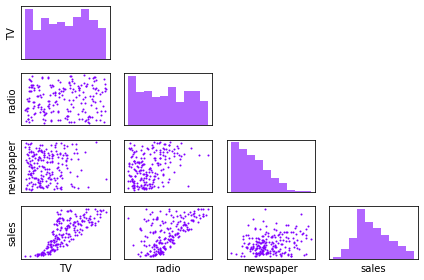

In [6]:
from fomlads.model.basis_functions import construct_rbf_feature_mapping
from fomlads.evaluate.eval_regression import train_and_test_filter
from fomlads.evaluate.eval_regression import train_and_test_partition
from fomlads.evaluate.eval_regression import train_and_test_linear_model
from fomlads.evaluate.eval_regression import evaluate_linear_model
from fomlads.plot.exploratory import plot_scatter_array
from fomlads.plot.evaluations import plot_train_test_errors
from fomlads.data.external import import_data_simple

## Provided code for Ex. 6 a) and c)
ifname = '/data/datasets/fomlads/advertising/advertising.csv'
data, field_names = import_data_simple(
        ifname, delimiter=',', header=True, columns=np.arange(1,5))
plot_scatter_array(data, field_names)
N = data.shape[0]
inputs = data[:,[0,1,2]]
targets = data[:,3]

# let's inspect the data a little more
tv_spend = inputs[:,0]
radio_spend = inputs[:,1]
newspaper_spend = inputs[:,2]

print(f"TV spend - mean:{np.mean(tv_spend):.1f}, std:{np.std(tv_spend):.1f}")
print(f"Radio spend - mean:{np.mean(radio_spend):.1f}, std:{np.std(radio_spend):.1f}")
print(f"Newspaper spend - mean:{np.mean(newspaper_spend):.1f}, std:{np.std(newspaper_spend):.1f}")

In [7]:
## Complete Ex. 6 a), c) and e) here

## Exercise 6.6 solutions

*Write your markdown solutions here.*